# Figure S6d — Cross-release UHVDB cluster consistency

Evaluate homogeneity, completeness, and v-measure of UHVDB clusters across consecutive releases (r1→r2→r3→r4) at genomovar, species, and AAI taxonomic ranks. Also report raw counts of clusters that are split, merged, or retained 1:1 among shared genomes.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from sklearn.metrics import v_measure_score
from sklearn.metrics.cluster import completeness_score, homogeneity_score

sns.set_theme(
    style="ticks",
    context="notebook",
    rc={
        "font.size": 14,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "figure.titlesize": 14,
    },
)
plt.rcParams["font.size"] = 14

AXIS_FONTDICT = {"fontweight": "bold"}


def style_axes(g, xlabel: str, ylabel: str) -> None:
    """Apply bold axis labels to every subplot in a seaborn FacetGrid."""
    for ax in g.axes.flat:
        ax.set_xlabel(xlabel, fontdict=AXIS_FONTDICT)
        ax.set_ylabel(ylabel, fontdict=AXIS_FONTDICT)


FIG1 = Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_1")

RELEASE_PATHS = {
    "r1": FIG1 / "uhgv_hq_hc_results/uhvdb_2026-03-23",
    "r2": FIG1 / "uhgv_hq_lc_results/uhvdb_2026-03-25",
    "r3": FIG1 / "uhvdb_virus_db_results/uhvdb_2026-03-26",
    "r4": FIG1 / "uhvdb_human_metag_results/uhvdb_2026-03-26-2",
}

RELEASE_PAIRS = [("r1", "r2"), ("r2", "r3"), ("r3", "r4")]
RANKS = ["genomovar", "species", "subgenus", "genus", "subfamily", "family"]
RANK_COLS = {
    "genomovar": "genomovar_cluster_id",
    "species": "species_cluster_id",
    "family": "family_cluster_id",
    "subfamily": "subfamily_cluster_id",
    "genus": "genus_cluster_id",
    "subgenus": "subgenus_cluster_id",
}

## Load release cluster tables

In [3]:
def load_release_tables(release_dir: Path) -> dict[str, pl.DataFrame]:
    """Load genomovar, species, and AAI cluster membership tables for one release."""
    return {
        "genomovars": pl.read_csv(
            release_dir / "uhvdb_genomovars_info.tsv.gz",
            separator="\t",
            columns=["uhvdb_id", "cluster_id", "votu_rep"],
        ),
        "species": pl.read_csv(
            release_dir / "uhvdb_species_info.tsv.gz",
            separator="\t",
            columns=["uhvdb_id", "cluster_id", "votu_rep"],
        ),
        "aaicluster": pl.read_csv(
            release_dir / "uhvdb_aaicluster.tsv.gz",
            separator="\t",
        ),
    }


releases = {name: load_release_tables(path) for name, path in RELEASE_PATHS.items()}

for name, tables in releases.items():
    print(
        f"{name}: "
        f"{tables['genomovars'].height:,} genomes, "
        f"{tables['genomovars']['cluster_id'].n_unique():,} genomovars, "
        f"{tables['species']['cluster_id'].n_unique():,} species, "
        f"{tables['aaicluster']['family_cluster_id'].n_unique():,} families"
    )

r1: 179,392 genomes, 156,387 genomovars, 53,595 species, 815 families
r2: 181,979 genomes, 158,727 genomovars, 54,296 species, 839 families
r3: 405,961 genomes, 362,846 genomovars, 144,742 species, 1,247 families
r4: 576,190 genomes, 508,382 genomovars, 199,442 species, 1,444 families


## Build genome → rank label frames

Propagate species and AAI labels onto every genome via genomovar rep → species rep joins (same pattern as figure_s18).

In [4]:
def build_membership(tables: dict[str, pl.DataFrame]) -> pl.DataFrame:
    """Return one row per genome with cluster IDs at all ranks."""
    genomovars = tables["genomovars"].rename(
        {
            "cluster_id": "genomovar_cluster_id",
            "votu_rep": "genomovar_rep",
        }
    )
    species = (
        tables["species"]
        .rename(
            {
                "uhvdb_id": "genomovar_rep",
                "cluster_id": "species_cluster_id",
                "votu_rep": "species_rep",
            }
        )
        .unique("genomovar_rep")
    )
    aaicluster = (
        tables["aaicluster"]
        .rename({"uhvdb_id": "species_rep"})
        .unique("species_rep")
    )

    return (
        genomovars
        .join(species, on="genomovar_rep", how="left")
        .join(aaicluster, on="species_rep", how="left")
        .select(
            [
                "uhvdb_id",
                "genomovar_cluster_id",
                "species_cluster_id",
                "family_cluster_id",
                "subfamily_cluster_id",
                "genus_cluster_id",
                "subgenus_cluster_id",
            ]
        )
    )


membership = {name: build_membership(tables) for name, tables in releases.items()}

for name, df in membership.items():
    n_missing_species = df.filter(pl.col("species_cluster_id").is_null()).height
    n_missing_family = df.filter(pl.col("family_cluster_id").is_null()).height
    print(
        f"{name}: {df.height:,} genomes; "
        f"missing species={n_missing_species:,}, missing family={n_missing_family:,}"
    )

r1: 179,392 genomes; missing species=0, missing family=0
r2: 181,979 genomes; missing species=0, missing family=0
r3: 405,961 genomes; missing species=0, missing family=0
r4: 576,190 genomes; missing species=0, missing family=0


## Consistency metrics and split / merge counts

For each consecutive release pair and rank, restrict to shared `uhvdb_id`s.

- **homogeneity** (`labels_true=prior`, `labels_pred=new`): lowered by merges of distinct prior clusters
- **completeness**: lowered by splits of a prior cluster across new clusters
- **v-measure**: harmonic mean of homogeneity and completeness
- **split**: prior clusters mapping to >1 new cluster
- **merge**: prior clusters mapping to exactly one new cluster that itself contains members from >1 prior cluster
- **1:1 unchanged**: prior clusters with exactly one new partner that itself maps to exactly one prior cluster

Split, merge, and 1:1 partition the prior clusters, so `frac_split + frac_merge + frac_one_to_one = 1`.


In [5]:
def split_merge_counts(prior: pl.Series, new: pl.Series) -> dict[str, int]:
    """Count split, merge, and 1:1 relationships among prior clusters.

    - split: prior cluster maps to >1 new cluster
    - merge: prior cluster maps to exactly 1 new cluster that contains >1 prior
    - 1:1: prior cluster maps to exactly 1 new cluster that contains only that prior
    """
    pairs = pl.DataFrame({"prior": prior, "new": new}).unique()

    prior_n_new = pairs.group_by("prior").agg(pl.col("new").n_unique().alias("n_new"))
    new_n_prior = pairs.group_by("new").agg(pl.col("prior").n_unique().alias("n_prior"))

    prior_status = (
        pairs
        .join(prior_n_new, on="prior")
        .join(new_n_prior, on="new")
        .group_by("prior")
        .agg(
            pl.col("n_new").first(),
            pl.col("n_prior").max().alias("max_n_prior_in_new"),
        )
    )

    n_split = prior_status.filter(pl.col("n_new") > 1).height
    n_merge = prior_status.filter(
        (pl.col("n_new") == 1) & (pl.col("max_n_prior_in_new") > 1)
    ).height
    n_one_to_one = prior_status.filter(
        (pl.col("n_new") == 1) & (pl.col("max_n_prior_in_new") == 1)
    ).height

    return {
        "n_prior_clusters": prior.n_unique(),
        "n_new_clusters": new.n_unique(),
        "n_split": n_split,
        "n_merge": n_merge,
        "n_one_to_one": n_one_to_one,
    }


def score_pair(
    prior_df: pl.DataFrame,
    new_df: pl.DataFrame,
    rank: str,
    prior_name: str,
    new_name: str,
) -> dict:
    """Compute h/c/v and split/merge counts for one release pair and rank."""
    col = RANK_COLS[rank]
    joined = (
        prior_df
        .select(["uhvdb_id", pl.col(col).alias("prior")])
        .join(
            new_df.select(["uhvdb_id", pl.col(col).alias("new")]),
            on="uhvdb_id",
            how="inner",
        )
        .filter(pl.col("prior").is_not_null() & pl.col("new").is_not_null())
        .sort("uhvdb_id")
    )

    prior_labels = joined["prior"]
    new_labels = joined["new"]
    counts = split_merge_counts(prior_labels, new_labels)

    return {
        "pair": f"{prior_name}→{new_name}",
        "prior": prior_name,
        "new": new_name,
        "rank": rank,
        "n_shared_genomes": joined.height,
        "homogeneity": homogeneity_score(prior_labels, new_labels),
        "completeness": completeness_score(prior_labels, new_labels),
        "v_measure": v_measure_score(prior_labels, new_labels),
        **counts,
        "frac_split": counts["n_split"] / counts["n_prior_clusters"] if counts["n_prior_clusters"] else float("nan"),
        "frac_merge": counts["n_merge"] / counts["n_prior_clusters"] if counts["n_prior_clusters"] else float("nan"),
        "frac_one_to_one": counts["n_one_to_one"] / counts["n_prior_clusters"] if counts["n_prior_clusters"] else float("nan"),
    }


results_rows = []
for prior_name, new_name in RELEASE_PAIRS:
    for rank in RANKS:
        results_rows.append(
            score_pair(
                membership[prior_name],
                membership[new_name],
                rank=rank,
                prior_name=prior_name,
                new_name=new_name,
            )
        )

results = pl.DataFrame(results_rows).with_columns(
    pl.col("rank").cast(pl.Enum(RANKS))
)
results


pair,prior,new,rank,n_shared_genomes,homogeneity,completeness,v_measure,n_prior_clusters,n_new_clusters,n_split,n_merge,n_one_to_one,frac_split,frac_merge,frac_one_to_one
str,str,str,enum,i64,f64,f64,f64,i64,i64,i64,i64,i64,f64,f64,f64
"""r1→r2""","""r1""","""r2""","""genomovar""",179392,0.999997,1.0,0.999998,156387,156384,0,4,156383,0.0,0.000026,0.999974
"""r1→r2""","""r1""","""r2""","""species""",179392,0.999883,0.999873,0.999878,53595,53583,25,61,53509,0.000466,0.001138,0.998395
"""r1→r2""","""r1""","""r2""","""subgenus""",179392,0.99828,0.998269,0.998274,38042,37971,281,570,37191,0.007387,0.014983,0.97763
"""r1→r2""","""r1""","""r2""","""genus""",179392,0.998504,0.998101,0.998302,18547,18535,218,359,17970,0.011754,0.019356,0.96889
"""r1→r2""","""r1""","""r2""","""subfamily""",179392,0.998235,0.999019,0.998627,7028,7011,105,167,6756,0.01494,0.023762,0.961298
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""r3→r4""","""r3""","""r4""","""species""",405961,0.998697,0.999195,0.998946,144742,144040,556,1809,142377,0.003841,0.012498,0.983661
"""r3→r4""","""r3""","""r4""","""subgenus""",405961,0.997373,0.997259,0.997316,82497,82332,1019,1722,79756,0.012352,0.020873,0.966775
"""r3→r4""","""r3""","""r4""","""genus""",405961,0.997454,0.997458,0.997456,34920,34858,792,1339,32789,0.02268,0.038345,0.938975


### Summary tables

In [6]:
metrics_table = results.select(
    [
        "pair",
        "rank",
        "n_shared_genomes",
        "n_prior_clusters",
        "n_new_clusters",
        "homogeneity",
        "completeness",
        "v_measure",
    ]
)
metrics_table

pair,rank,n_shared_genomes,n_prior_clusters,n_new_clusters,homogeneity,completeness,v_measure
str,enum,i64,i64,i64,f64,f64,f64
"""r1→r2""","""genomovar""",179392,156387,156384,0.999997,1.0,0.999998
"""r1→r2""","""species""",179392,53595,53583,0.999883,0.999873,0.999878
"""r1→r2""","""subgenus""",179392,38042,37971,0.99828,0.998269,0.998274
"""r1→r2""","""genus""",179392,18547,18535,0.998504,0.998101,0.998302
"""r1→r2""","""subfamily""",179392,7028,7011,0.998235,0.999019,0.998627
…,…,…,…,…,…,…,…
"""r3→r4""","""species""",405961,144742,144040,0.998697,0.999195,0.998946
"""r3→r4""","""subgenus""",405961,82497,82332,0.997373,0.997259,0.997316
"""r3→r4""","""genus""",405961,34920,34858,0.997454,0.997458,0.997456


In [7]:
split_merge_table = results.select(
    [
        "pair",
        "rank",
        "n_prior_clusters",
        "n_new_clusters",
        "n_split",
        "n_merge",
        "n_one_to_one",
        "frac_split",
        "frac_merge",
        "frac_one_to_one",
    ]
)
split_merge_table

pair,rank,n_prior_clusters,n_new_clusters,n_split,n_merge,n_one_to_one,frac_split,frac_merge,frac_one_to_one
str,enum,i64,i64,i64,i64,i64,f64,f64,f64
"""r1→r2""","""genomovar""",156387,156384,0,4,156383,0.0,0.000026,0.999974
"""r1→r2""","""species""",53595,53583,25,61,53509,0.000466,0.001138,0.998395
"""r1→r2""","""subgenus""",38042,37971,281,570,37191,0.007387,0.014983,0.97763
"""r1→r2""","""genus""",18547,18535,218,359,17970,0.011754,0.019356,0.96889
"""r1→r2""","""subfamily""",7028,7011,105,167,6756,0.01494,0.023762,0.961298
…,…,…,…,…,…,…,…,…,…
"""r3→r4""","""species""",144742,144040,556,1809,142377,0.003841,0.012498,0.983661
"""r3→r4""","""subgenus""",82497,82332,1019,1722,79756,0.012352,0.020873,0.966775
"""r3→r4""","""genus""",34920,34858,792,1339,32789,0.02268,0.038345,0.938975


## Plots

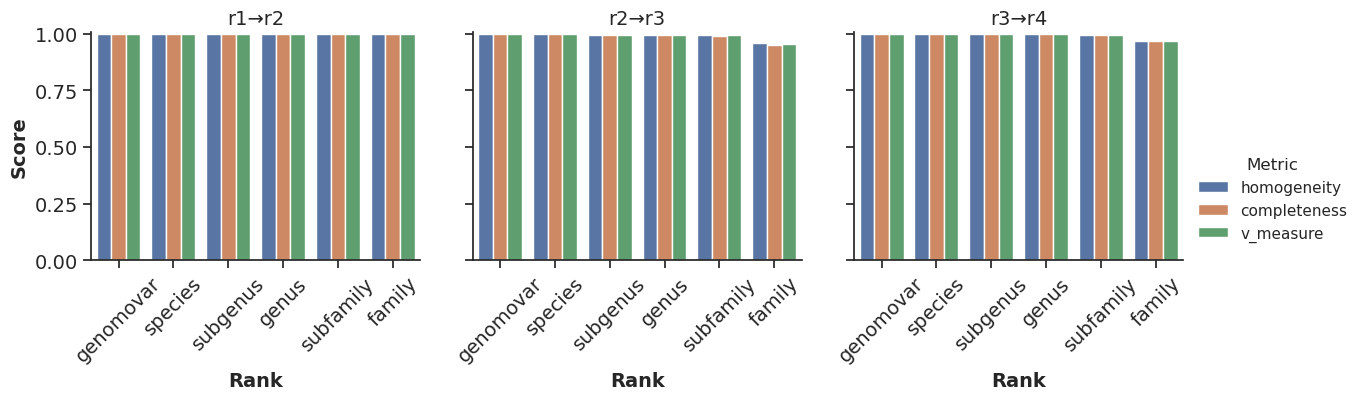

In [8]:
metrics_long = (
    results
    .select(["pair", "rank", "homogeneity", "completeness", "v_measure"])
    .unpivot(
        index=["pair", "rank"],
        on=["homogeneity", "completeness", "v_measure"],
        variable_name="Metric",
        value_name="score",
    )
    .to_pandas()
)

g = sns.catplot(
    data=metrics_long,
    x="rank",
    y="score",
    hue="Metric",
    col="pair",
    kind="bar",
    order=RANKS,
    height=3.5,
    aspect=1.15,
    legend_out=True,
)
style_axes(g, "Rank", "Score")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0.0, 1.005)
plt.show()

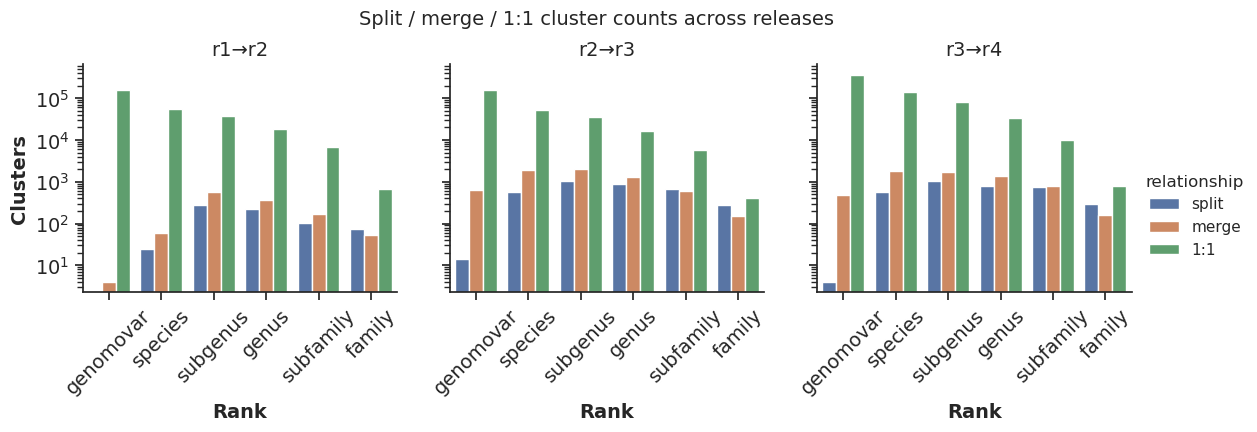

In [9]:
counts_long = (
    results
    .select(["pair", "rank", "n_split", "n_merge", "n_one_to_one"])
    .unpivot(
        index=["pair", "rank"],
        on=["n_split", "n_merge", "n_one_to_one"],
        variable_name="relationship",
        value_name="count",
    )
    .with_columns(
        pl.col("relationship").replace(
            {
                "n_split": "split",
                "n_merge": "merge",
                "n_one_to_one": "1:1",
            }
        )
    )
    .to_pandas()
)

g = sns.catplot(
    data=counts_long,
    x="rank",
    y="count",
    hue="relationship",
    col="pair",
    kind="bar",
    order=RANKS,
    height=3.5,
    aspect=1.15,
    legend_out=True,
)
style_axes(g, "Rank", "Clusters")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.set_yscale("log")
g.fig.suptitle("Split / merge / 1:1 cluster counts across releases", y=1.03)
plt.show()

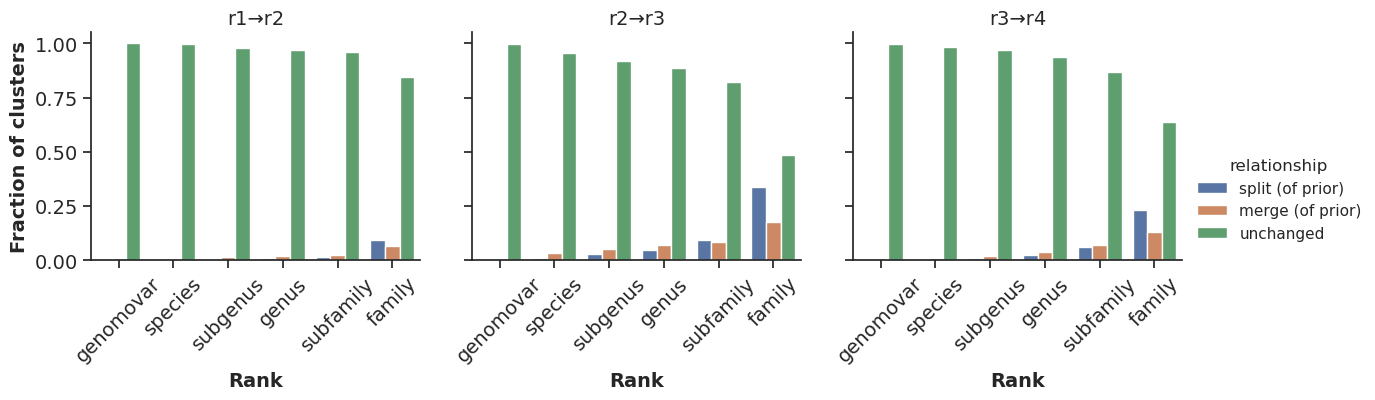

In [10]:
frac_long = (
    results
    .select(["pair", "rank", "frac_split", "frac_merge", "frac_one_to_one"])
    .unpivot(
        index=["pair", "rank"],
        on=["frac_split", "frac_merge", "frac_one_to_one"],
        variable_name="relationship",
        value_name="fraction",
    )
    .with_columns(
        pl.col("relationship").replace(
            {
                "frac_split": "split (of prior)",
                "frac_merge": "merge (of prior)",
                "frac_one_to_one": "unchanged",
            }
        )
    )
    .to_pandas()
)

g = sns.catplot(
    data=frac_long,
    x="rank",
    y="fraction",
    hue="relationship",
    col="pair",
    kind="bar",
    order=RANKS,
    height=3.5,
    aspect=1.15,
    legend_out=True,
)
style_axes(g, "Rank", "Fraction of clusters")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, 1.05)
plt.show()


## r1-anchored comparisons (r1→r2, r1→r3, r1→r4)

Same metrics and split/merge counts as above, but always using r1 as the prior labeling versus each later release.

In [11]:
R1_ANCHORED_PAIRS = [("r1", "r2"), ("r1", "r3"), ("r1", "r4")]

results_r1_rows = []
for prior_name, new_name in R1_ANCHORED_PAIRS:
    for rank in RANKS:
        results_r1_rows.append(
            score_pair(
                membership[prior_name],
                membership[new_name],
                rank=rank,
                prior_name=prior_name,
                new_name=new_name,
            )
        )

results_r1 = pl.DataFrame(results_r1_rows).with_columns(
    pl.col("rank").cast(pl.Enum(RANKS))
)
results_r1

pair,prior,new,rank,n_shared_genomes,homogeneity,completeness,v_measure,n_prior_clusters,n_new_clusters,n_split,n_merge,n_one_to_one,frac_split,frac_merge,frac_one_to_one
str,str,str,enum,i64,f64,f64,f64,i64,i64,i64,i64,i64,f64,f64,f64
"""r1→r2""","""r1""","""r2""","""genomovar""",179392,0.999997,1.0,0.999998,156387,156384,0,4,156383,0.0,0.000026,0.999974
"""r1→r2""","""r1""","""r2""","""species""",179392,0.999883,0.999873,0.999878,53595,53583,25,61,53509,0.000466,0.001138,0.998395
"""r1→r2""","""r1""","""r2""","""subgenus""",179392,0.99828,0.998269,0.998274,38042,37971,281,570,37191,0.007387,0.014983,0.97763
"""r1→r2""","""r1""","""r2""","""genus""",179392,0.998504,0.998101,0.998302,18547,18535,218,359,17970,0.011754,0.019356,0.96889
"""r1→r2""","""r1""","""r2""","""subfamily""",179392,0.998235,0.999019,0.998627,7028,7011,105,167,6756,0.01494,0.023762,0.961298
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""r1→r4""","""r1""","""r4""","""species""",179392,0.996615,0.997875,0.997245,53595,52946,577,1964,51054,0.010766,0.036645,0.952589
"""r1→r4""","""r1""","""r4""","""subgenus""",179392,0.993927,0.99397,0.993949,38042,37765,1151,2259,34632,0.030256,0.059382,0.910362
"""r1→r4""","""r1""","""r4""","""genus""",179392,0.993383,0.99194,0.992661,18547,18598,945,1434,16168,0.050952,0.077317,0.871731


### Summary tables (r1-anchored)

In [12]:
metrics_table_r1 = results_r1.select(
    [
        "pair",
        "rank",
        "n_shared_genomes",
        "n_prior_clusters",
        "n_new_clusters",
        "homogeneity",
        "completeness",
        "v_measure",
    ]
)
metrics_table_r1

pair,rank,n_shared_genomes,n_prior_clusters,n_new_clusters,homogeneity,completeness,v_measure
str,enum,i64,i64,i64,f64,f64,f64
"""r1→r2""","""genomovar""",179392,156387,156384,0.999997,1.0,0.999998
"""r1→r2""","""species""",179392,53595,53583,0.999883,0.999873,0.999878
"""r1→r2""","""subgenus""",179392,38042,37971,0.99828,0.998269,0.998274
"""r1→r2""","""genus""",179392,18547,18535,0.998504,0.998101,0.998302
"""r1→r2""","""subfamily""",179392,7028,7011,0.998235,0.999019,0.998627
…,…,…,…,…,…,…,…
"""r1→r4""","""species""",179392,53595,52946,0.996615,0.997875,0.997245
"""r1→r4""","""subgenus""",179392,38042,37765,0.993927,0.99397,0.993949
"""r1→r4""","""genus""",179392,18547,18598,0.993383,0.99194,0.992661


In [13]:
split_merge_table_r1 = results_r1.select(
    [
        "pair",
        "rank",
        "n_prior_clusters",
        "n_new_clusters",
        "n_split",
        "n_merge",
        "n_one_to_one",
        "frac_split",
        "frac_merge",
        "frac_one_to_one",
    ]
)
split_merge_table_r1

pair,rank,n_prior_clusters,n_new_clusters,n_split,n_merge,n_one_to_one,frac_split,frac_merge,frac_one_to_one
str,enum,i64,i64,i64,i64,i64,f64,f64,f64
"""r1→r2""","""genomovar""",156387,156384,0,4,156383,0.0,0.000026,0.999974
"""r1→r2""","""species""",53595,53583,25,61,53509,0.000466,0.001138,0.998395
"""r1→r2""","""subgenus""",38042,37971,281,570,37191,0.007387,0.014983,0.97763
"""r1→r2""","""genus""",18547,18535,218,359,17970,0.011754,0.019356,0.96889
"""r1→r2""","""subfamily""",7028,7011,105,167,6756,0.01494,0.023762,0.961298
…,…,…,…,…,…,…,…,…,…
"""r1→r4""","""species""",53595,52946,577,1964,51054,0.010766,0.036645,0.952589
"""r1→r4""","""subgenus""",38042,37765,1151,2259,34632,0.030256,0.059382,0.910362
"""r1→r4""","""genus""",18547,18598,945,1434,16168,0.050952,0.077317,0.871731


### Plots (r1-anchored)

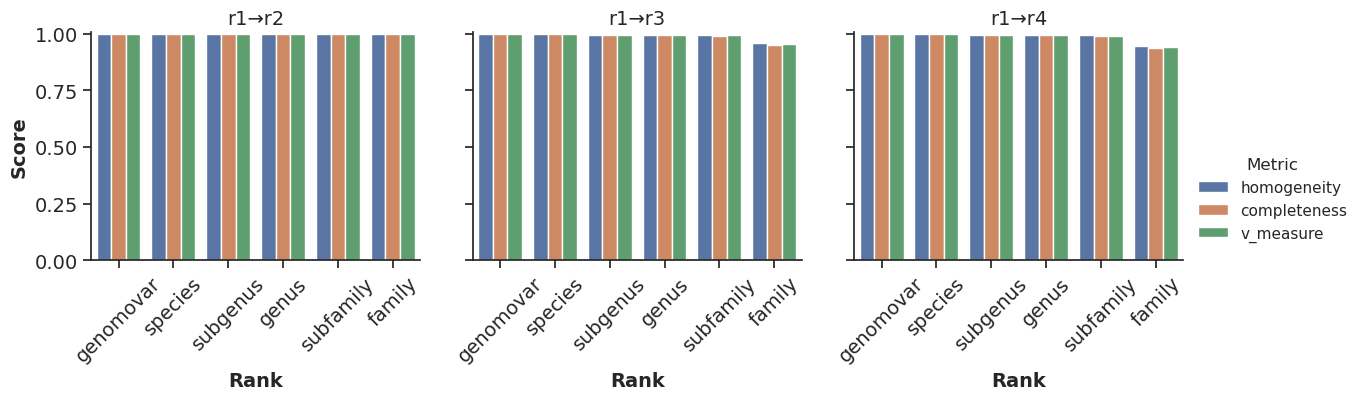

In [14]:
metrics_long_r1 = (
    results_r1
    .select(["pair", "rank", "homogeneity", "completeness", "v_measure"])
    .unpivot(
        index=["pair", "rank"],
        on=["homogeneity", "completeness", "v_measure"],
        variable_name="Metric",
        value_name="score",
    )
    .to_pandas()
)

g = sns.catplot(
    data=metrics_long_r1,
    x="rank",
    y="score",
    hue="Metric",
    col="pair",
    kind="bar",
    order=RANKS,
    height=3.5,
    aspect=1.15,
    legend_out=True,
)
style_axes(g, "Rank", "Score")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0.0, 1.005)
plt.show()

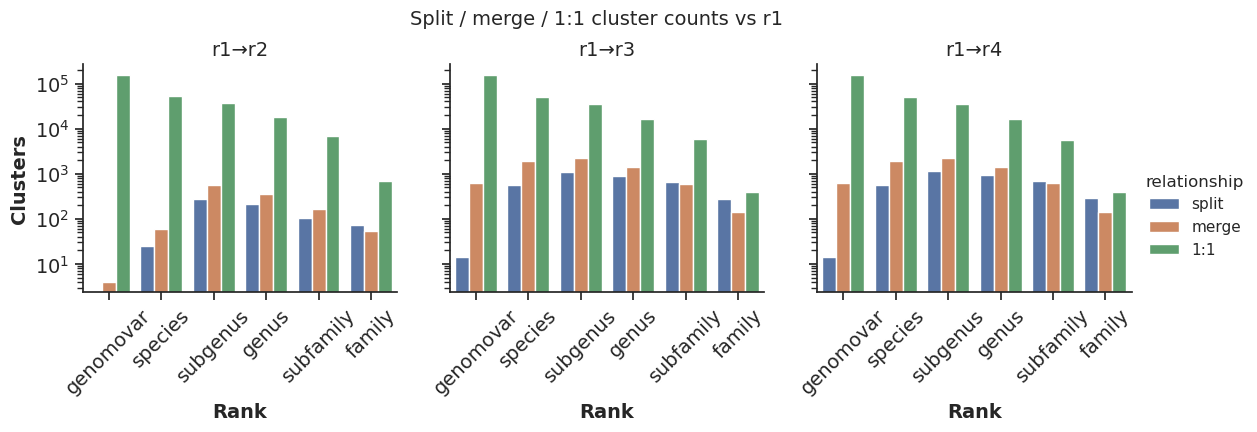

In [15]:
counts_long_r1 = (
    results_r1
    .select(["pair", "rank", "n_split", "n_merge", "n_one_to_one"])
    .unpivot(
        index=["pair", "rank"],
        on=["n_split", "n_merge", "n_one_to_one"],
        variable_name="relationship",
        value_name="count",
    )
    .with_columns(
        pl.col("relationship").replace(
            {
                "n_split": "split",
                "n_merge": "merge",
                "n_one_to_one": "1:1",
            }
        )
    )
    .to_pandas()
)

g = sns.catplot(
    data=counts_long_r1,
    x="rank",
    y="count",
    hue="relationship",
    col="pair",
    kind="bar",
    order=RANKS,
    height=3.5,
    aspect=1.15,
    legend_out=True,
)
style_axes(g, "Rank", "Clusters")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.set_yscale("log")
g.fig.suptitle("Split / merge / 1:1 cluster counts vs r1", y=1.03)
plt.show()

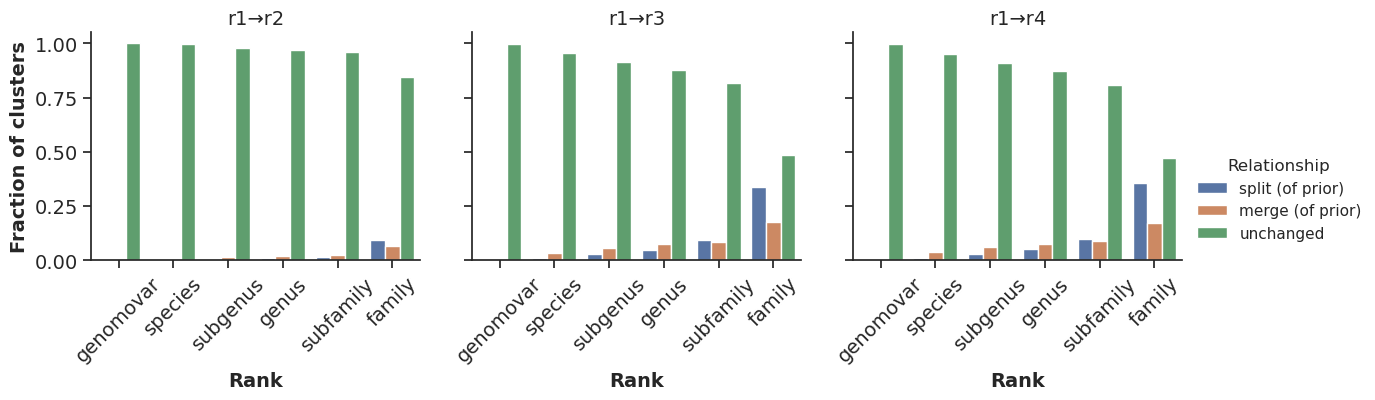

In [16]:
frac_long_r1 = (
    results_r1
    .select(["pair", "rank", "frac_split", "frac_merge", "frac_one_to_one"])
    .unpivot(
        index=["pair", "rank"],
        on=["frac_split", "frac_merge", "frac_one_to_one"],
        variable_name="Relationship",
        value_name="fraction",
    )
    .with_columns(
        pl.col("Relationship").replace(
            {
                "frac_split": "split (of prior)",
                "frac_merge": "merge (of prior)",
                "frac_one_to_one": "unchanged",
            }
        )
    )
    .to_pandas()
)

g = sns.catplot(
    data=frac_long_r1,
    x="rank",
    y="fraction",
    hue="Relationship",
    col="pair",
    kind="bar",
    order=RANKS,
    height=3.5,
    aspect=1.15,
    legend_out=True,
)
style_axes(g, "Rank", "Fraction of clusters")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, 1.05)
plt.show()


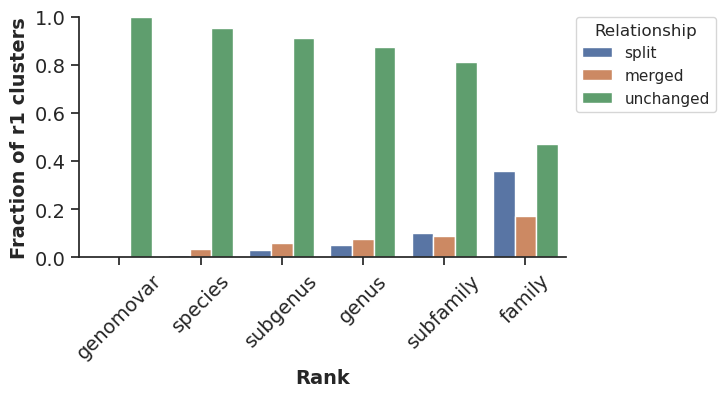

In [20]:
# just compare r1 to r4
frac_long_r1_r4 = (
    results_r1
    .filter(pl.col("pair") == "r1→r4")
    .select(["rank", "frac_split", "frac_merge", "frac_one_to_one"])
    .unpivot(
        index=["rank"],
        on=["frac_split", "frac_merge", "frac_one_to_one"],
        variable_name="relationship",
        value_name="fraction",
    )
    .with_columns(
        pl.col("relationship").replace(
            {
                "frac_split": "split",
                "frac_merge": "merged",
                "frac_one_to_one": "unchanged",
            }
        )
    )
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.barplot(
    data=frac_long_r1_r4,
    x="rank",
    y="fraction",
    hue="relationship",
    order=RANKS,
    hue_order=["split", "merged", "unchanged"],
    ax=ax,
)
ax.set_xlabel("Rank", fontdict=AXIS_FONTDICT)
ax.set_ylabel("Fraction of r1 clusters", fontdict=AXIS_FONTDICT)
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Relationship", frameon=True, loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


## Notes

Releases are cumulative catalog expansions (HQ+HC → HQ+LC → virus DBs → human metagenomes). Metrics are computed only on genomes present in both releases of each pair, so scores reflect how shared genomes are reassigned when the clustering catalog grows rather than agreement on genomes unique to the later release.

The first section compares consecutive releases (r1→r2, r2→r3, r3→r4). The second anchors all comparisons to r1 (r1→r2, r1→r3, r1→r4) to show how much the original clustering diverges as later genomes are added.